In [1]:
from optimize_team_location import *

 36%|██████████████████████████████████████▍                                                                   | 725/2000 [01:48<03:10,  6.69it/s]


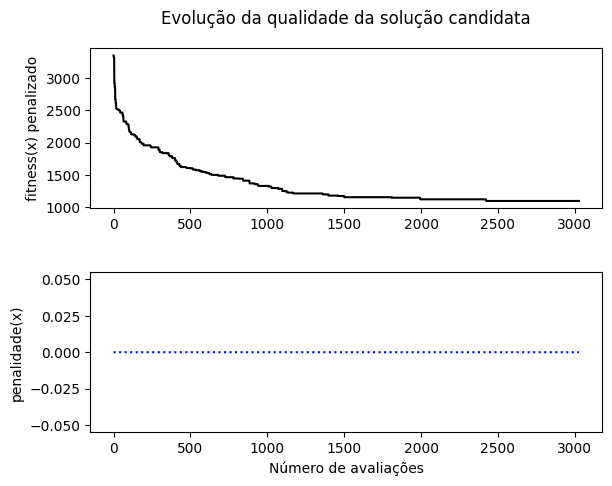

 43%|█████████████████████████████████████████████▊                                                            | 865/2000 [02:16<02:58,  6.35it/s]


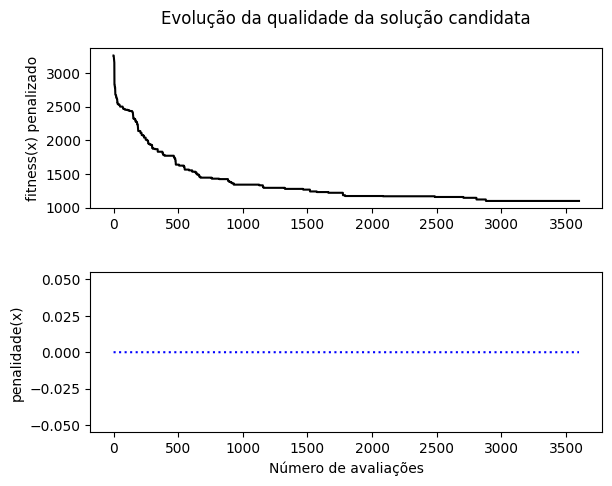

 45%|███████████████████████████████████████████████▉                                                          | 905/2000 [02:23<02:53,  6.29it/s]


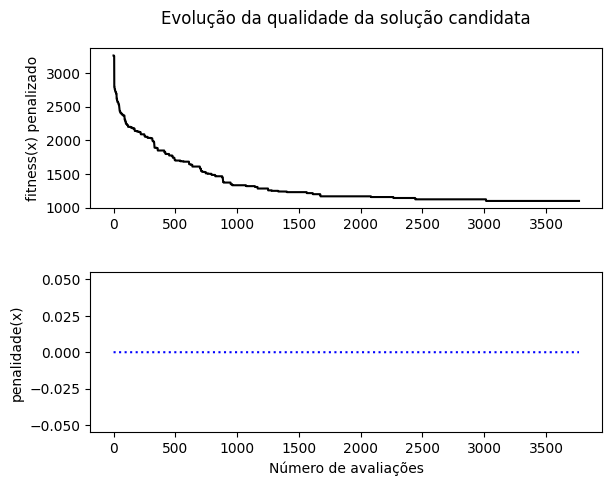

 50%|████████████████████████████████████████████████████▋                                                     | 994/2000 [02:34<02:35,  6.45it/s]


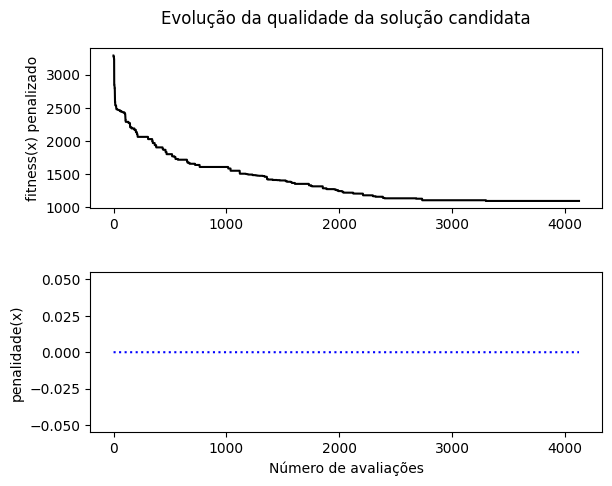

 46%|████████████████████████████████████████████████▍                                                         | 914/2000 [02:22<02:49,  6.41it/s]


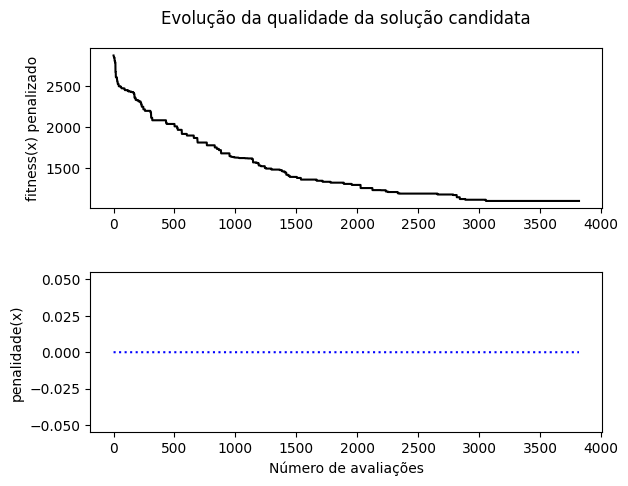

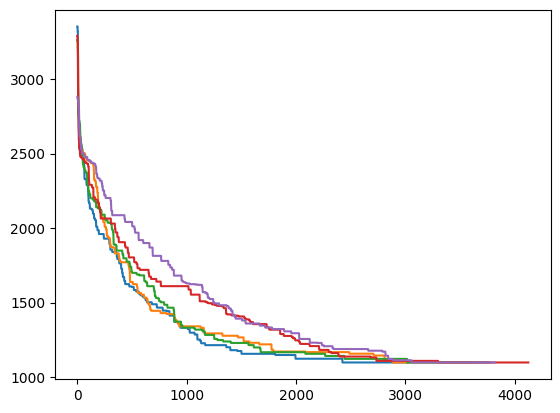

In [3]:
historicos_f1 = optimize(minimiza_distancias, max_it=int(2e3), follow_optimizitation=True)
for historico in historicos_f1:
    plt.plot(historico.fit)

 23%|█████████████████████████                                                                                  | 117/500 [00:07<00:24, 15.38it/s]


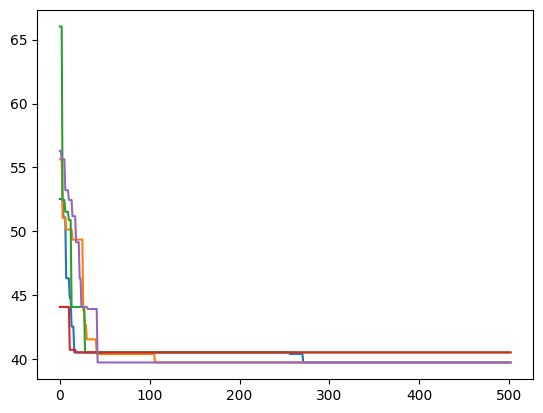

In [4]:
historicos_f2 = optimize(minimiza_distancia_maxima, max_it=500)
for historico in historicos_f2:
    plt.plot(historico.fit)

In [4]:
for historico in historicos_f2:
    print(historico.best_solution)

solution(ativo_equipe=array([1, 0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2, 1, 2, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 0, 0,
       2, 1, 1, 1, 2, 2, 2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 0, 1, 1,
       2, 0, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0, 1, 2, 2, 2, 0, 1, 1, 1, 1, 2,
       1, 0, 2, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 2, 0]), equipe_base=array([2, 2, 2]), fitness=np.float64(40.51486718), penalidade=0, multi_fitness={})
solution(ativo_equipe=array([2, 1, 0, 1, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 2, 0, 1, 2,
       0, 2, 1, 2, 2, 0, 2, 2, 0, 1, 0, 1, 1, 2, 2, 2, 2, 2, 0, 2, 1, 0,
       0, 0, 2, 0, 2, 2, 0, 1, 0, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 2,
       0, 1, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 1, 2, 2, 1, 1, 0, 1, 2, 2, 2,
       2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 2, 2, 2, 0,
       0, 2, 0, 0, 1, 1, 1, 0, 0, 2, 0, 0, 1, 0, 0]), equipe_base=array([4, 4

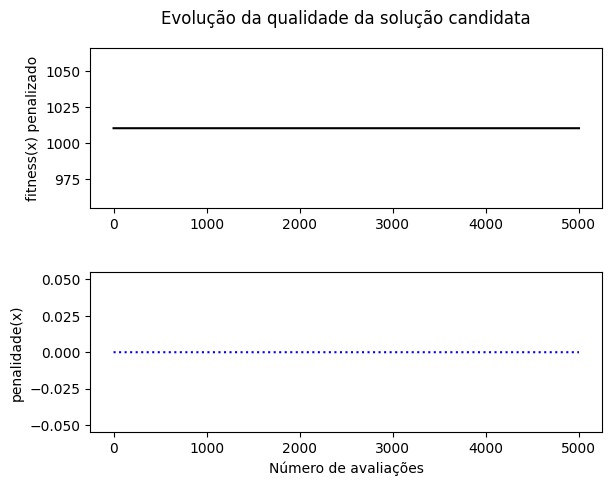

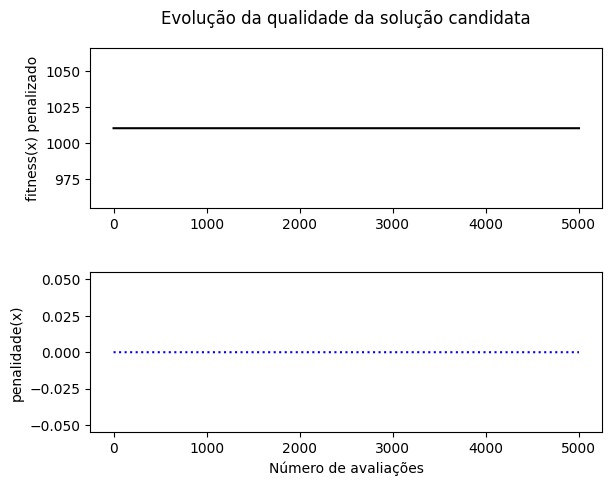

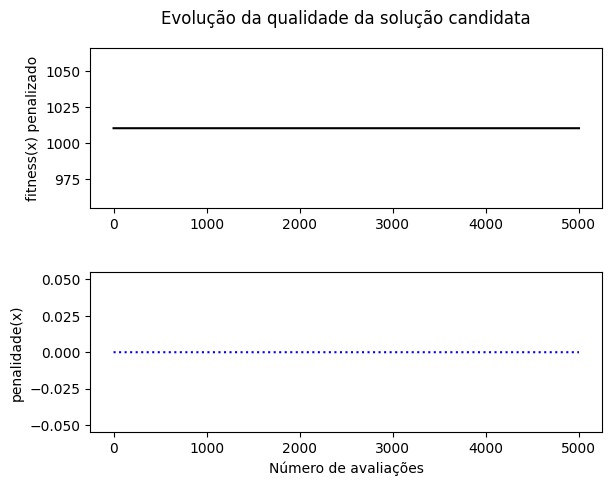

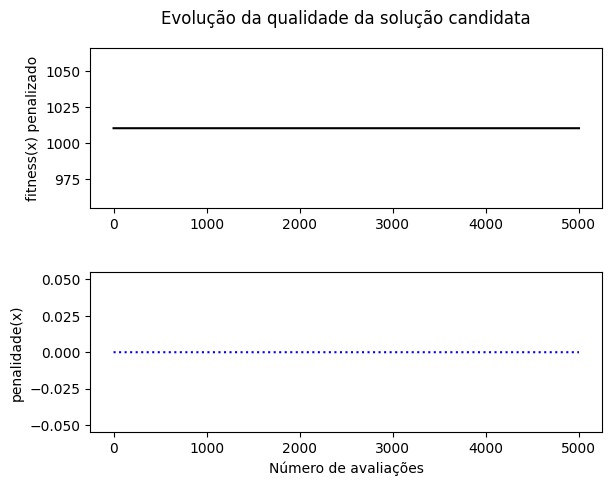

In [ ]:
historicos = []
for _ in range(5):
    # Contador do número de soluções candidatas avaliadas
    num_sol_avaliadas = 0
    
    # Máximo número de soluções candidatas avaliadas
    max_num_sol_avaliadas = 5e3
    
    # Número de estruturas de vizinhanças definidas
    kmax = 3
    
    # Faz a leitura dos dados da instância do problema
    prob_def = get_problem_definition()
    
    # Gera solução inicial
    x = sol_inicial(prob_def, apply_constructive_heuristic=True, use_random=False)
    
    # Avalia solução inicial
    x = minimiza_distancias(x, prob_def)
    num_sol_avaliadas += 1
    
    # Armazena dados para plot
    historico = history(20e3)
    historico.update(x)
    
    historico = BasicVNS(
        prob_def=prob_def,
        initial_solution=x,
        objective_function=minimiza_distancias,
        max_iteration=max_num_sol_avaliadas,
        historico=historico
    )
    historicos.append(historico)

    # print('\n--- SOLUÇÃO INICIAL CONSTRUÍDA ---\n')
    # print('Identificação dos projetos selecionados:\n')
    # print('x = {}\n'.format(historico.sol[0]))
    # print('fitness(x) = {:.2f}\n'.format(historico.fit[0]))
    # print('fitness(x) penalizado = {:.2f}\n'.format(historico.fit_pen[0]))
    # print('penalidade(x) = {:.2f}\n'.format(historico.pen[0]))
    
    # print('\n--- MELHOR SOLUÇÃO ENCONTRADA ---\n')
    # print('Identificação dos projetos selecionados:\n')
    # print('x = {}\n'.format(x.ativo_base))
    # print('fitness(x) = {:.2f}\n'.format(x.fitness))
    # print('fitness(x) penalizado = {:.2f}\n'.format(x.fitness_penalizado))
    # print('penalidade(x) = {:.2f}\n'.format(x.penalidade))
    
    fig, (ax1, ax2) = plt.subplots(2, 1)
    s = len(historico.fit_pen)
    ax1.plot(np.linspace(0, s - 1, s), historico.fit_pen, 'k-')
    ax2.plot(np.linspace(0, s - 1, s), historico.pen, 'b:')
    fig.suptitle('Evolução da qualidade da solução candidata')
    ax1.set_ylabel('fitness(x) penalizado')
    ax2.set_ylabel('penalidade(x)')
    ax2.set_xlabel('Número de avaliações')
    plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.9,
                        top=0.9,
                        wspace=0.4,
                        hspace=0.4)
    plt.show()


In [ ]:
# historicos = optimize(minimiza_distancias)
for i, historico in enumerate(historicos):
    plt.plot(historico.fit, label=f"Teste {i}")
plt.legend()
plt.title("Convegência para função de minimização de distâncias")
plt.xlabel('Iterações')
plt.ylabel("Distância total");

In [ ]:
resultados = []
for historico in historicos:
    resultados.append(historico.best_solution.fitness)
    
resultados = np.array(resultados)
resultados.std()

In [ ]:
resultados.min()

In [ ]:
bases_map = {v:k for k, v in prob_def.base_map.items()}
ativos_map = {v:k for k, v in prob_def.ativo_map.items()}

In [10]:
def plot_location(location_map, label, alpha=1, title=None, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color='blue'):
    """
    Plota os pontos representados em 'location_map' no gráfico, com vários parâmetros personalizáveis.

    Parameters:
    - location_map: Dicionário de localização.
    - label: Texto para o label da legenda.
    - alpha: Nível de transparência para os pontos (0 a 1).
    - title: Título do gráfico (opcional).
    - xlabel: Rótulo para o eixo x (opcional).
    - ylabel: Rótulo para o eixo y (opcional).
    - legend_loc: Localização da legenda (opcional).
    """

    # Extraindo as coordenadas lat e long
    lat = [location[0] for location in location_map.values()]
    long = [location[1] for location in location_map.values()]

    # Plotando os pontos
    plt.scatter(lat, long, label=label, alpha=alpha, color=color)

    # Configurando o título e rótulos dos eixos
    if title:
        plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Configurando a legenda
    plt.legend(loc=legend_loc)

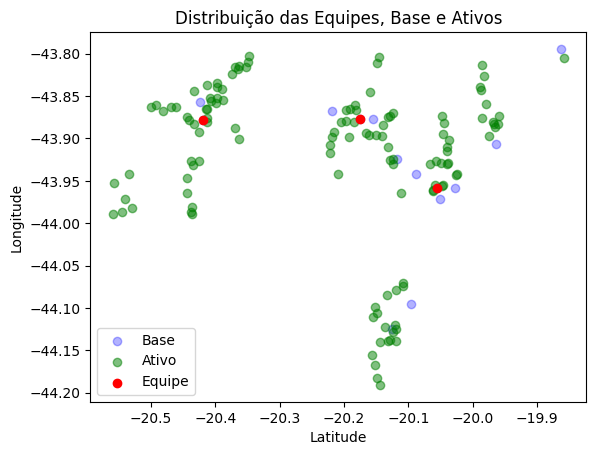

In [11]:
# Reverter os mapas e plotar com informações mais detalhadas
inverse_base_map = {v: k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'Base', alpha=0.3, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'blue')

inverse_ativo_map = {v: k for k, v in prob_def.ativo_map.items()}
plot_location(inverse_ativo_map, 'Ativo', alpha=0.5, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'green')

# Plotando a equipe com base no mapeamento
equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
plot_location(equipe_map, 'Equipe', alpha=1,  title='Distribuição das Equipes, Base e Ativos', xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'red')

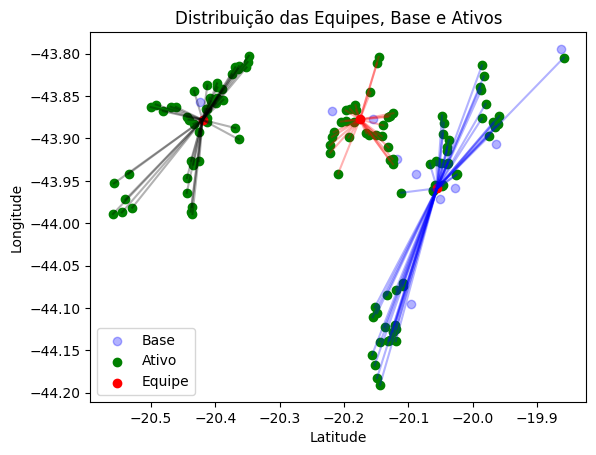

In [12]:
best = [h.best_solution for h in historicos if h.best_solution.fitness == resultados.min()][0]

# Reverter os mapas e plotar com informações mais detalhadas
inverse_base_map = {v: k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'Base', alpha=0.3, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'blue')

inverse_ativo_map = {v: k for k, v in prob_def.ativo_map.items()}
plot_location(inverse_ativo_map, 'Ativo', alpha=1, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'green')

# Plotando a equipe com base no mapeamento
equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(best.equipe_base)}
plot_location(equipe_map, 'Equipe', alpha=1,  title='Distribuição das Equipes, Base e Ativos', xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'red')

bases = np.unique(best.ativo_base)
colors = {
    bases[0]: 'black', 
    bases[1]: 'red', 
    bases[2]: 'blue'
}

for ativo, base in enumerate(best.ativo_base):
    x_coords = [ativos_map[ativo][0], bases_map[base][0]]
    y_coords = [ativos_map[ativo][1], bases_map[base][1]]
    
    plt.plot(x_coords, y_coords, color=colors[base], alpha=0.3)

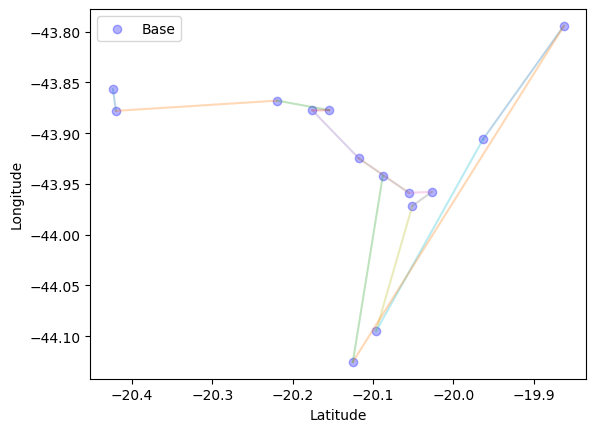

In [13]:
# Reverter os mapas e plotar com informações mais detalhadas
inverse_base_map = {v: k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'Base', alpha=0.3, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'blue')

for base in inverse_base_map.keys():
    if base==13:
        break
    # print(base)
    x_coords = [inverse_base_map[base][0], inverse_base_map[base+1][0]]
    y_coords = [inverse_base_map[base][1], inverse_base_map[base+1][1]]
    # plt.arrow(*x_coords, *y_coords)
    # break
    plt.plot(x_coords, y_coords, alpha=0.3)

# inverse_ativo_map = {v: k for k, v in prob_def.ativo_map.items()}
# plot_location(inverse_ativo_map, 'Ativo', alpha=0.5, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'green')

# # Plotando a equipe com base no mapeamento
# equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
# plot_location(equipe_map, 'Equipe', alpha=1,  title='Distribuição das Equipes, Base e Ativos', xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'red')

In [14]:
len(inverse_base_map)

14

In [15]:
best = [h.best_solution for h in historicos_eq if h.best_solution.fitness == np.array(resultados_eq).min()][0]

# Reverter os mapas e plotar com informações mais detalhadas
inverse_base_map = {v: k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'Base', alpha=0.3, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'blue')

inverse_ativo_map = {v: k for k, v in prob_def.ativo_map.items()}
plot_location(inverse_ativo_map, 'Ativo', alpha=1, xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'green')

# Plotando a equipe com base no mapeamento
equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(best.equipe_base)}
plot_location(equipe_map, 'Equipe', alpha=1,  title='Distribuição das Equipes, Base e Ativos', xlabel='Latitude', ylabel='Longitude', legend_loc='best', color = 'red')

bases = np.unique(best.ativo_base)
colors = {
    bases[0]: 'black', 
    bases[1]: 'red', 
    # bases[2]: 'blue'
}

for ativo, base in enumerate(best.ativo_base):
    x_coords = [ativos_map[ativo][0], bases_map[base][0]]
    y_coords = [ativos_map[ativo][1], bases_map[base][1]]
    
    plt.plot(x_coords, y_coords, color=colors[base], alpha=0.3)

NameError: name 'historicos_eq' is not defined

In [16]:
best.equipe_base

array([6, 1, 4])

In [17]:
[h.best_solution.equipe_base for h in historicos_eq]

NameError: name 'historicos_eq' is not defined

In [18]:
best.fitness_penalizado

np.float64(1098.4750294259998)

In [19]:
best.fitness

np.float64(1098.4750294259998)

In [20]:
best.ativo_base[0]

np.int64(6)

In [21]:
bases_map = {v:k for k, v in prob_def.base_map.items()}
ativos_map = {v:k for k, v in prob_def.ativo_map.items()}

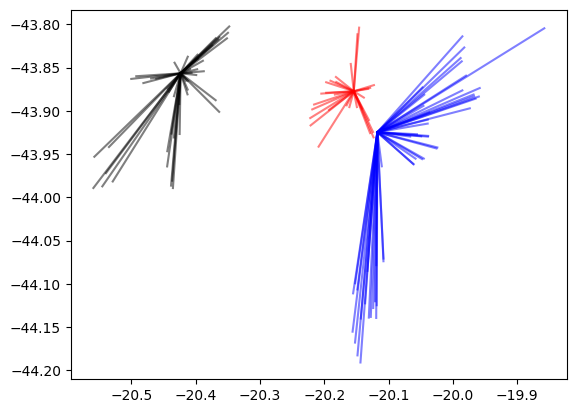

In [22]:
bases = np.unique(best.ativo_base)
colors = {
    bases[0]: 'black', 
    bases[1]: 'red', 
    bases[2]: 'blue'
}

for ativo, base in enumerate(best.ativo_base):
    x_coords = [ativos_map[ativo][0], bases_map[base-1][0]]
    y_coords = [ativos_map[ativo][1], bases_map[base-1][1]]
    
    plt.plot(x_coords, y_coords, color=colors[base], alpha=0.5)

In [23]:
np.unique(best.ativo_equipe)

array([0, 1, 2])

In [24]:
best.equipe_base

array([6, 1, 4])

In [25]:
best.ativo_equipe

array([0, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 1, 2, 0, 0,
       0, 0, 0, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [26]:
resultados = []
for historico in historicos:
    resultados.append(historico.best_solution.fitness)
    
resultados = np.array(resultados)
resultados.std()

np.float64(0.0)

In [27]:
resultados.min()

np.float64(1098.4750294259998)

In [28]:
resultados.max()

np.float64(1098.4750294259998)

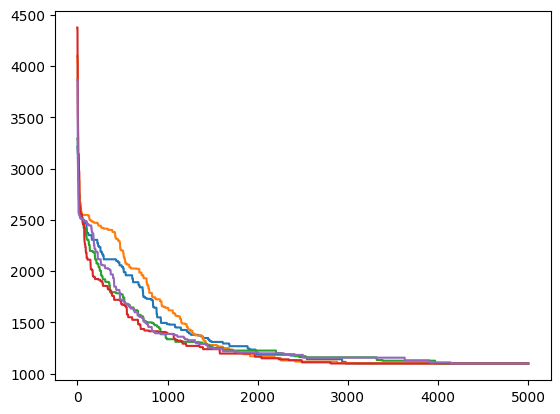

In [29]:
# historicos = optimize(minimiza_distancias)
for historico in historicos:
    plt.plot(historico.fit)

In [25]:
resultados = []
for historico in historicos:
    # if historico.best_solution.fitness > 2800:
    #     continue
    resultados.append(historico.best_solution.fitness)
    
resultados = np.array(resultados)
resultados.std()

np.float64(43.16600272408743)

In [26]:
resultados.mean()

np.float64(1557.9968902482003)

In [27]:
resultados.max()

np.float64(1610.395467686001)

In [28]:
resultados.min()

np.float64(1490.048613317)

In [60]:
[h.best_solution for h in historicos if h.best_solution.fitness == resultados.min()]

[solution(ativo_equipe=array([0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 1, 1, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0,
        0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 0, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
        1, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 0, 2, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]), equipe_base=array([6, 1, 2]), fitness=np.float64(1476.0334482630008), penalidade=0)]

In [63]:
[h.best_solution for h in historicos_eq if h.best_solution.fitness == np.array(resultados_eq).min()]

[solution(ativo_equipe=array([2, 1, 2, 0, 1, 1, 1, 2, 0, 1, 0, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2,
        1, 0, 1, 1, 0, 1, 2, 1, 2, 2, 0, 0, 1, 1, 2, 1, 1, 0, 0, 2, 0, 0,
        2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 0, 0, 1, 2, 0, 1, 0, 1, 1, 2, 0, 0,
        0, 0, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0,
        2, 0, 1, 0, 0, 1, 0, 1, 0, 2, 1, 1, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2,
        2, 0, 2, 1, 0, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2]), equipe_base=array([ 6, 10, 10]), fitness=1, penalidade=0),
 solution(ativo_equipe=array([1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 2, 2, 1, 2, 2, 2, 2, 1,
        0, 0, 2, 0, 2, 0, 1, 1, 0, 0, 2, 2, 0, 1, 2, 1, 0, 0, 2, 2, 2, 1,
        1, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2, 0, 1, 1, 1, 0, 2, 2, 1,
        2, 1, 1, 1, 1, 0, 2, 1, 2, 1, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 0, 0,
        2, 0, 2, 0, 2, 2, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 2,
        1, 2, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 2]), equipe_base=array([10,  9,  5]), fitness=1, pen

In [32]:
resultados_eq = []
historicos_eq = optimize(minimiza_distancia_maxima, min_iterations=100)
for historico in historicos_eq:
    plt.plot(historico.fit)#[:20000])
    resultados_eq.append(historico.best_solution.fitness)


plt.title("Convegência para função de Equilibrio de ativos")
plt.xlabel('Iterações')
plt.ylabel("Diferença entre a quantidade de ativos\n da equipe mais sobrecarregada \ne a menos sobrecarregada");

TypeError: optimize() got an unexpected keyword argument 'min_iterations'

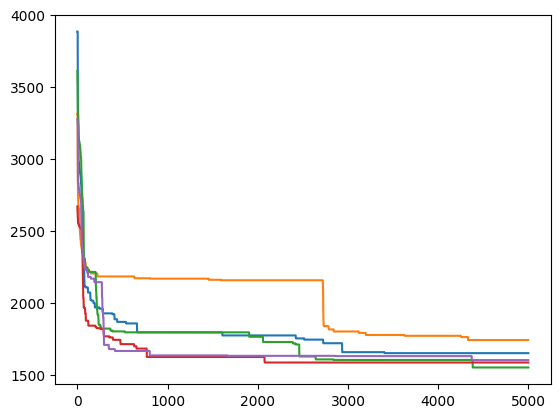

In [23]:
# historicos = optimize(minimiza_distancias)
for historico in historicos:
    plt.plot(historico.fit[:5000])

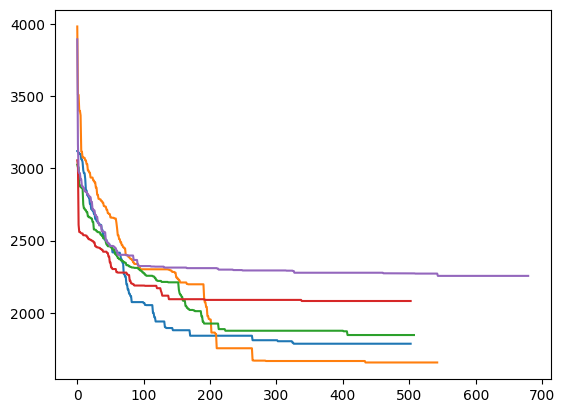

In [4]:
# historicos = optimize(minimiza_distancias)
for historico in historicos:
    plt.plot(historico.fit)

In [5]:
resultados = []
for historico in historicos:
    # if historico.best_solution.fitness > 2800:
    #     continue
    resultados.append(historico.best_solution.fitness)
    
resultados = np.array(resultados)
resultados.std()

np.float64(215.08590892561168)

In [6]:
resultados.mean()

np.float64(1925.3162609848005)

In [7]:
resultados.max()

np.float64(2255.5246332279994)

In [8]:
resultados.min()

np.float64(1656.5522965400005)

In [ ]:
# def optimize(fobj, apply_constructive_heuristic=False):
#     historicos = []
#     for _ in range(5):
#         # Contador do número de soluções candidatas avaliadas
#         num_sol_avaliadas = 0
        
#         # Máximo número de soluções candidatas avaliadas
#         max_num_sol_avaliadas = 40e3
        
#         # Número de estruturas de vizinhanças definidas
#         kmax = 3
        
#         # Faz a leitura dos dados da instância do problema
#         prob_def = get_problem_definition()
        
#         # Gera solução inicial
#         x = sol_inicial(prob_def, apply_constructive_heuristic=apply_constructive_heuristic)
        
#         # Avalia solução inicial
#         x = fobj(x, prob_def)
#         num_sol_avaliadas += 1
        
#         # Armazena dados para plot
#         historico = history(min_iterations)
#         historico.update(x)
        
#         historico = BasicVNS(
#             prob_def=prob_def,
#             initial_solution=x,
#             objective_function=fobj,
#             max_iteration=max_num_sol_avaliadas,
#             historico=historico
#         )
#         historicos.append(historico)
#     return historicos

In [ ]:
historicos = optimize(equilibrio_ativos, min_iterations=100)
for historico in historicos:
    plt.plot(historico.fit)

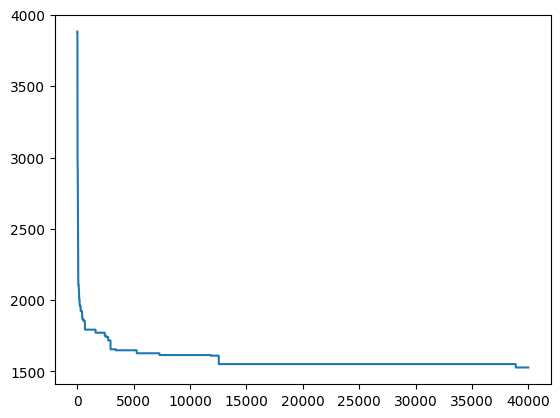

In [30]:
plt.plot(historicos[0].fit)

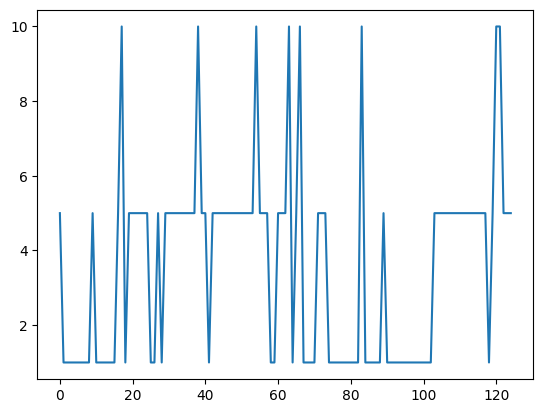

In [35]:
plt.plot(historicos[0].sol[-1].ativo_base)

In [37]:
np.count_nonzero(historicos[0].sol[-1].ativo_base)

125

In [12]:
historicos[0].sol[-1].equipe_base

array([ 6, 13,  1])

In [34]:
historicos_equilibrio = optimize(equilibrio_ativos, apply_constructive_heuristic=True)
for historico in historicos_equilibrio:
    plt.plot(historico.fit[:100])

NameError: name 'min_iterations' is not defined

In [ ]:
historicos[0].sol[-1].equipe_base

In [ ]:
historicos_equilibrio[0].sol[-1].equipe_base

In [ ]:
historicos[0].sol[-1].equipe_base

In [ ]:
historicos[0].sol[-1].fitness

In [ ]:
historicos_equilibrio[0].sol[-1].fitness

In [ ]:
historicos = optimize(minimiza_distancias)
for historico in historicos:
    plt.plot(historico.fit)

In [ ]:
historicos_random = []
for _ in range(5):
    # Contador do número de soluções candidatas avaliadas
    num_sol_avaliadas = 0
    
    # Máximo número de soluções candidatas avaliadas
    max_num_sol_avaliadas = 40e3
    
    # Número de estruturas de vizinhanças definidas
    kmax = 3
    
    # Faz a leitura dos dados da instância do problema
    prob_def = get_problem_definition()
    
    # Gera solução inicial
    x = sol_inicial(prob_def, apply_constructive_heuristic=False)
    
    # Avalia solução inicial
    x = minimiza_distancias(x, prob_def)
    num_sol_avaliadas += 1
    
    # Armazena dados para plot
    historico = history()
    historico.update(x)
    
    historico = BasicVNS(
        prob_def=prob_def,
        initial_solution=x,
        objective_function=minimiza_distancias,
        max_iteration=max_num_sol_avaliadas,
        historico=historico
    )
    historicos_random.append(historico)

for historico in historicos_random:
    plt.plot(historico.fit)

In [ ]:
historicos_random = []
for _ in range(5):
    # Contador do número de soluções candidatas avaliadas
    num_sol_avaliadas = 0
    
    # Máximo número de soluções candidatas avaliadas
    max_num_sol_avaliadas = 40e3
    
    # Número de estruturas de vizinhanças definidas
    kmax = 3
    
    # Faz a leitura dos dados da instância do problema
    prob_def = get_problem_definition()
    
    # Gera solução inicial
    x = sol_inicial(prob_def, apply_constructive_heuristic=False)
    
    # Avalia solução inicial
    x = minimiza_distancias(x, prob_def)
    num_sol_avaliadas += 1
    
    # Armazena dados para plot
    historico = history()
    historico.update(x)
    
    historico = BasicVNS(
        prob_def=prob_def,
        initial_solution=x,
        objective_function=equilibrio_ativos,
        max_iteration=max_num_sol_avaliadas,
        historico=historico
    )
    historicos_random.append(historico)

for historico in historicos_random:
    plt.plot(historico.fit)

In [ ]:
historicos_centroid_exato = []
for _ in range(5):
    # Contador do número de soluções candidatas avaliadas
    num_sol_avaliadas = 0
    
    # Máximo número de soluções candidatas avaliadas
    max_num_sol_avaliadas = 40e3
    
    # Número de estruturas de vizinhanças definidas
    kmax = 3
    
    # Faz a leitura dos dados da instância do problema
    prob_def = get_problem_definition()
    
    # Gera solução inicial
    x = sol_inicial(prob_def, apply_constructive_heuristic=True, use_random=False)
    
    # Avalia solução inicial
    x = minimiza_distancias(x, prob_def)
    num_sol_avaliadas += 1
    
    # Armazena dados para plot
    historico = history()
    historico.update(x)
    
    historico = BasicVNS(
        prob_def=prob_def,
        initial_solution=x,
        objective_function=minimiza_distancias,
        max_iteration=max_num_sol_avaliadas,
        historico=historico
    )
    historicos_centroid_exato.append(historico)



In [ ]:
for historico in historicos_centroid_exato:
    plt.plot(historico.fit)

plt.xlabel('Iterações')
plt.ylabel('Fitness')
plt.title('Convergência do algoritmo');

In [ ]:
for historico in historicos_random:
    plt.plot(historico.fit)

plt.xlabel('Iterações')
plt.ylabel('Fitness')
plt.title('Convergência do algoritmo');

In [ ]:
historicos_centroid_exato[0].best_solution.fitness_penalizado

In [ ]:
resultados = []
for historico in historicos:
    resultados.append(historico.best_solution.fitness)
    
resultados = np.array(resultados)
resultados.std()

In [ ]:
resultados.min()

In [ ]:
resultados.max()

In [ ]:
prob_def.base_map

In [ ]:
# inverse_base_map

In [ ]:
# lat = []
# long = []
# for base, location in inverse_base_map.items():
#     x, y = location
#     lat.append(x)
#     long.append(x)
# plt.scatter(lat, long)

In [ ]:
def plot_location(location_map, label, alpha=1):
    lat = []
    long = []
    for base, location in location_map.items():
        x, y = location
        lat.append(x)
        long.append(y)
    plt.scatter(lat, long, label=label, alpha=alpha)

In [ ]:
inverse_base_map = {v:k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'base')

inverse_ativo_map = {v:k for k, v in prob_def.ativo_map.items()}
plot_location(inverse_ativo_map, 'ativo', 0.4)

equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
plot_location(equipe_map, 'equipe')

In [ ]:
# !pip install scikit-learn

In [ ]:
from sklearn.cluster import KMeans


In [ ]:
df = pd.DataFrame(inverse_ativo_map).T
df.columns = ['latitude', 'longitude']
df.head()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df[['latitude', 'longitude']])

# Adicionando a coluna de labels ao DataFrame
df['cluster'] = kmeans.labels_

# Obtendo os centróides
centroids = kmeans.cluster_centers_

In [ ]:
loc_map = {}
for c, location in enumerate(centroids):
    # print(c)
    # print(location)
    loc_map[c] = location
plot_location(loc_map, 'centroides')

inverse_base_map = {v:k for k, v in prob_def.base_map.items()}
plot_location(inverse_base_map, 'base',0.2)

inverse_ativo_map = {v:k for k, v in prob_def.ativo_map.items()}
plot_location(inverse_ativo_map, 'ativo', 0.4)

equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
plot_location(equipe_map, 'equipe')
plt.legend()

In [ ]:
inverse_base_map = {v:k for k, v in prob_def.base_map.items()}
lat = []
long = []
for base, location in inverse_base_map.items():
    x, y = location
    lat.append(x)
    long.append(y)
plt.scatter(lat, long, label='base')

inverse_ativo_map = {v:k for k, v in prob_def.ativo_map.items()}
lat = []
long = []
for base, location in inverse_ativo_map.items():
    x, y = location
    lat.append(x)
    long.append(y)
plt.scatter(lat, long, alpha=0.4, label='ativo')

equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
lat = []
long = []
for equipe, location in equipe_map.items():
    x, y = location
    lat.append(x)
    long.append(y)
plt.scatter(lat, long, label='equipe')

plt.legend()

In [ ]:
equipe_map = {eq: inverse_base_map[b] for eq, b in enumerate(historicos[0].best_solution.equipe_base)}
lat = []
long = []
for equipe, location in equipe_map.items():
    x, y = location
    lat.append(x)
    long.append(y)
plt.scatter(lat, long)

In [ ]:
inverse_base_map

In [ ]:
inverse_ativo_map[0]

In [ ]:
data = pd.read_csv("probdata.csv", delimiter=";", header=None, decimal=',', names=[
    "Latitude_Base", "Longitude_Base", "Latitude_Ativo", "Longitude_Ativo", "Distância"
])
data.head()

In [ ]:
plt.scatter(data['Latitude_Base'], data['Longitude_Base'], alpha=1, label='bases')
plt.scatter(data['Latitude_Ativo'], data['Longitude_Ativo'], alpha=1, label='ativos')
plt.legend()

In [ ]:
inverse_ativo_map = {v:k for k, v in prob_def.ativo_map.items()}
lat = []
long = []
for base, location in inverse_ativo_map.items():
    x, y = location
    lat.append(x)
    long.append(x)
plt.scatter(lat, long)

In [ ]:
len(lat)

In [ ]:
sns.histplot(p)

In [ ]:
np.max(p)

In [ ]:
np.min(p)